# Exercise 04: Histogram

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/checking-logs.sqlite')

## Loading data

In [2]:
df = pd.read_sql("""
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%'
""", conn, parse_dates=['timestamp'])

In [3]:
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5
df['date'] = df['timestamp'].dt.date

## Absolute commits per (date, hour) 

In [4]:
counts = df.groupby(['date', 'hour', 'is_weekend']).size().reset_index(name='hours')

## Splitting into two lists

In [ ]:
working_day = df[df['is_weekend'] == False]['hour']
weekend = df[df['is_weekend'] == True]['hour']

## Plotting histogram

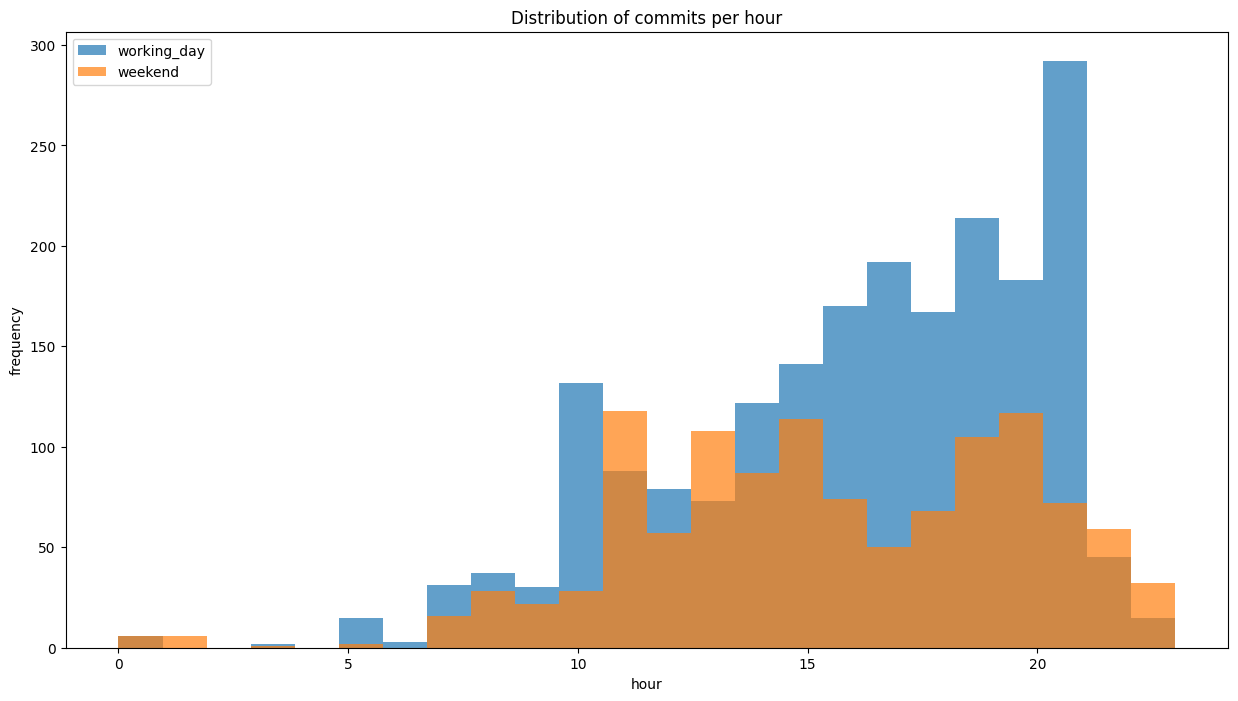

In [6]:
plt.figure(figsize=(15,8))

plt.hist(working_day, bins=24, alpha=0.7, label='working_day')
plt.hist(weekend, bins=24, alpha=0.7, label='weekend')

plt.legend()
plt.title('Distribution of commits per hour')
plt.xlabel('hour')
plt.ylabel('frequency')

plt.show()

In [7]:
## IF NEEDED, DATA WAS DERIVED FROM THIS CODE

# top4 = (
#     counts
#     .pivot_table(index=['date','hour'], columns='is_weekend', values='hours', fill_value=0)
# )

# top4.columns = ['working_day', 'weekend']

# top4 = top4[top4['weekend'] > top4['working_day']] \
#     .sort_values(by='weekend', ascending=False) \
#     .head(4)

# top4

#### Are there hours when the total number of commits was higher on weekends than on working days?

Yes.

Top four examples where weekend activity exceeded working day activity:
number of commits (working_day, weekend)
                      
- 2020-05-02 at 11:00  (0, 84) 
- 2020-04-26 at 20:00  (0, 54)
- 2020-05-10 at 13:00  (0, 48)
- 2020-04-26 at 19:00  (0, 47) 
